In [2]:
!hostname

n38.clstr


In [2]:
#%run /center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_submitting_jobs/extracting_case_studies.py


In [1]:
import pandas as pd 
import requests
import io
import numpy as np
import matplotlib.pyplot as plt
import glob
import xarray as xr
import geopandas as gpd
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
winter_months = [11, 12, 1, 2, 3]

Alaska Shapefiles 
-

In [3]:
shapefile_path = "/center1/DYNDOWN/phutton5/ROS/boundaries/Alaska_Borough_and_Census_Area_Boundaries.shp"
borough_boundaries = gpd.read_file(shapefile_path)
borough_boundaries = borough_boundaries.set_crs(epsg=3338)
borough_boundaries = borough_boundaries.to_crs(epsg=4326)
FNSB_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Fairbanks North Star Borough']
FNSB_geom = FNSB_boundary.geometry.iloc[0] 
FNSB_coords = []
FNSB_coords.extend(list(FNSB_geom.exterior.coords))
FNSB_coords = np.array(FNSB_coords)  
FNSB_coords = pd.DataFrame({
    "lon": FNSB_coords[:, 0],
    "lat": FNSB_coords[:, 1]})

Fairbanks_lat=(64.84)
Fairbanks_lon=(-147.72)

In [4]:
#Rick thoman data 
#https://docs.google.com/spreadsheets/d/1MUeq6N2F8OGBeYOa226iCbaVQBOxj01ibf5IwYqt5nI/edit?gid=0#gid=0
url = "https://docs.google.com/spreadsheets/d/1MUeq6N2F8OGBeYOa226iCbaVQBOxj01ibf5IwYqt5nI/export?format=csv&id=1MUeq6N2F8OGBeYOa226iCbaVQBOxj01ibf5IwYqt5nI&gid=0"
rick_df = pd.read_csv(url)

rick_df['Year'] = pd.to_numeric(rick_df['Year'], errors='coerce')
rick_df['month'] = pd.to_numeric(rick_df['Month'], errors='coerce')
rick_df['Rain Precip Amount (mm)'] = pd.to_numeric(rick_df['Rain Precip Amount (mm)'],errors='coerce')

rick_season_df = rick_df.loc[rick_df['month'].isin([11, 12, 1, 2, 3])].copy()
season_start = rick_season_df['Year'].where(~rick_season_df['month'].isin([1, 2, 3]),rick_season_df['Year'] - 1)
season_end = season_start + 1

rick_season_df['season'] = (season_start.astype(int).astype(str)+ '-'+ season_end.astype(int).astype(str))
rick_season_df['season_sum_rain_mm'] = (rick_season_df.groupby('season')['Rain Precip Amount (mm)'].transform('sum'))
#rick_monthly = rick_season_df.groupby('month')['Rain Precip Amount (mm)'].sum(numeric_only=True)
#rick_monthly=rick_monthly.reindex(winter_months).values #correct order 
rick_season_df = rick_season_df[rick_season_df['Year'] >= 1950]

In [5]:
rick_season_df_small=rick_season_df[['season','Year','month','Date ','Rain Precip Amount (mm)']].reset_index(drop=True)
#rick_season_df_small

rick_clean = rick_season_df_small.groupby(
    ['season', 'month'], as_index=False
).agg({'Rain Precip Amount (mm)': 'sum' })

rick_clean=rick_clean[rick_clean['Rain Precip Amount (mm)']!=0]
rick_clean.rename(columns={'Rain Precip Amount (mm)': 'Local'}, inplace=True)
rick_clean=rick_clean[rick_clean['Local']>=.254]
rick_clean

,season,month,Local
0,1954-1955,3,0.254
1,1956-1957,1,0.762
2,1960-1961,1,1.016
3,1962-1963,1,14.478
4,1962-1963,12,7.112
5,1966-1967,3,6.604
6,1967-1968,11,2.540
7,1967-1968,12,10.922
8,1969-1970,2,1.270
9,1970-1971,12,5.588


In [6]:
print(rick_clean['Local'].quantile(0.5))
print(rick_clean['Local'].quantile(0.9))

1.778
11.506200000000005


ASOS 
-

In [7]:
website='https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py?network=AK_ASOS&station=PAFA&data=p01m&data=wxcodes&data=metar&year1=1950&month1=1&day1=1&year2=2023&month2=3&day2=31&tz=Etc%2FUTC&format=onlycomma&latlon=yes&elev=yes&missing=M&trace=T&direct=no&report_type=3&report_type=4'
#https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py?network=AK_ASOS&station=PAFA&data=tmpc&data=p01m&data=wxcodes&data=snowdepth&year1=1950&month1=1&day1=1&year2=2023&month2=12&day2=9&tz=America%2FAnchorage&format=onlycomma&latlon=yes&elev=no&missing=M&trace=T&direct=no&report_type=3&report_type=4'
response = requests.get(website)
if response.status_code == 200:
    data = io.StringIO(response.text)
    df = pd.read_csv(data, comment="#")  
    print(df.head())
else:
    print("Error:", response.status_code)

KeyboardInterrupt: 

In [ ]:
df['valid'] = pd.to_datetime(df['valid'])
df['month'] = df['valid'].dt.month
df['date'] = df['valid'].dt.date
df['time'] = df['valid'].dt.time
#df['tmpc']
#df = df.drop(columns=['column_name'])
winter_df = df[df['month'].isin([11, 12, 1, 2, 3])] #filter to only keep the ROS months 

winter_df['date'] = pd.to_datetime(winter_df['date'])
year = winter_df['date'].dt.year
month = winter_df['date'].dt.month
season_start = year.where(~month.isin([1, 2, 3]), year - 1)
season_end = season_start + 1
winter_df['season'] = season_start.astype(str) + '-' + season_end.astype(str)

#filter to only when RA is present 
mask = winter_df['wxcodes'].str.contains('RA', na=False)
rain_and_mixed_df = winter_df[mask]
rain_and_mixed_df['p01m'] = rain_and_mixed_df['p01m'].replace('M', np.nan) 
rain_and_mixed_df['p01m'] = rain_and_mixed_df['p01m'].replace('T', 0.001) 
rain_and_mixed_df['p01m'] = pd.to_numeric(rain_and_mixed_df['p01m'], errors='coerce')

/center1/DYNDOWN/phutton5/VSCODE_dump/ipykernel_188243/1912088275.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  winter_df['date'] = pd.to_datetime(winter_df['date'])
/center1/DYNDOWN/phutton5/VSCODE_dump/ipykernel_188243/1912088275.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  winter_df['season'] = season_start.astype(str) + '-' + season_end.astype(str)
/center1/DYNDOWN/phutton5/VSCODE_dump/ipykernel_188243/1912088275.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sl

In [ ]:
monthly_order = [11, 12, 1, 2, 3]

seasonal_sum_rain_and_mixed_df = (rain_and_mixed_df.groupby('season')['p01m'].sum())
monthly_sum_by_season_ASOS = (rain_and_mixed_df.groupby(['month'])['p01m'].sum()) 
monthly_sum_by_season_ASOS=monthly_sum_by_season_ASOS.loc[monthly_order]

monthly_mean_by_season_ASOS = rain_and_mixed_df.groupby(['season'])['p01m'].mean()

start_years = seasonal_sum_rain_and_mixed_df.index.str.slice(0, 4).astype(int)
all_seasons = [f"{y}-{y+1}" for y in range(start_years.min(), start_years.max() + 1)]

seasonal_sum_rain_and_mixed_df = seasonal_sum_rain_and_mixed_df.reindex(all_seasons)
seasonal_sum_rain_and_mixed_df=seasonal_sum_rain_and_mixed_df.fillna(0)
seasons_seasonal_sum_rain_and_mixed_df = seasonal_sum_rain_and_mixed_df.index.tolist()

In [ ]:
filtered_rain_and_mixed_df = rain_and_mixed_df[(rain_and_mixed_df['p01m'].notna()) & (rain_and_mixed_df['p01m'] != 0)]
filtered_rain_and_mixed_df=(filtered_rain_and_mixed_df.groupby(['season', 'month'])['p01m'].sum().reset_index())

p90 = filtered_rain_and_mixed_df['p01m'].quantile(0.90)
p95 = filtered_rain_and_mixed_df['p01m'].quantile(0.95)
p75 = filtered_rain_and_mixed_df['p01m'].quantile(0.75)
p50 = filtered_rain_and_mixed_df['p01m'].quantile(0.5)
print(p50, p75,p90, p95)
#filtered_greatherthan_01_rain_and_mixed_df=filtered_rain_and_mixed_df[filtered_rain_and_mixed_df['p01m'] > 2.54]

filtered_90percentile_rain_and_mixed_df=filtered_rain_and_mixed_df[filtered_rain_and_mixed_df['p01m'] > 5.99]

0.76 1.5262499999999999 5.999900000000002 10.578499999999988


In [ ]:
merged = rick_season_df_small.merge(
    filtered_rain_and_mixed_df,
    on=['season', 'month'],
    how='left',
    indicator=True
)
#merge with only rick >= .254 mm (0.01 inches !!)

merged_test_rick_asos = merged.rename(
    columns={'Rain Precip Amount (mm)': 'Local'})

merged_test_rick_asos = merged_test_rick_asos.rename(
    columns={'p01m': 'PAFA'})

merged_test_rick_asos.drop(columns=['_merge'], inplace=True)
merged_test_rick_asos = merged_test_rick_asos.dropna(subset=['Local'])
merged_test_rick_asos=merged_test_rick_asos.replace(np.nan, 0)
merged_test_rick_asos

,season,Year,month,Date,Local,PAFA
0,1954-1955,1955,3,6,0.254,0.000
1,1956-1957,1957,1,20,0.762,0.000
2,1960-1961,1961,1,22,1.016,0.000
3,1962-1963,1962,12,24,7.112,2.290
4,1962-1963,1963,1,19-20,13.208,12.410
5,1962-1963,1963,1,15,1.270,12.410
6,1967-1968,1967,12,29-30,10.922,4.300
7,1967-1968,1967,11,21,2.540,3.040
8,1966-1967,1967,3,4,6.604,0.250
9,1970-1971,1970,12,24,5.588,4.060


Important for june 22
-


In [ ]:
seasonal_sum_rain_and_mixed_df = (rain_and_mixed_df.groupby('season')['p01m'].sum())
monthly_sum_ASOS = (rain_and_mixed_df.groupby(['month'])['p01m'].sum())
monthly_sum_ASOS=monthly_sum_ASOS.reindex(winter_months).values 

monthly_mean_by_season_ASOS = (rain_and_mixed_df.groupby(['season', 'month'])['p01m'].mean().unstack('month'))

start_years = seasonal_sum_rain_and_mixed_df.index.str.slice(0, 4).astype(int)
all_seasons = [f"{y}-{y+1}" for y in range(start_years.min(), start_years.max() + 1)]

seasonal_sum_rain_and_mixed_df = seasonal_sum_rain_and_mixed_df.reindex(all_seasons)
#seasonal_sum_rain_and_mixed_df=seasonal_sum_rain_and_mixed_df.fillna(0)
seasons_seasonal_sum_rain_and_mixed_df = seasonal_sum_rain_and_mixed_df.index.tolist()

In [ ]:
def getXY(lat, lon, dataarray):
    abslat = np.abs(dataarray.XLAT-lat)
    abslon = np.abs(dataarray.XLONG-lon)
    d = abslon**2 + abslat**2
    flat_index = np.argmin(d.values)
    yloc, xloc = np.unravel_index(flat_index, d.shape)
    return xloc, yloc

def getXY_latlon(lat, lon, dataarray):
    abslat = np.abs(dataarray.latitude - lat)
    abslon = np.abs(dataarray.longitude - lon)
    d = abslon**2 + abslat**2
    flat_index = np.argmin(d.values)
    yloc, xloc = np.unravel_index(flat_index, d.shape)
    return xloc, yloc

In [ ]:
regridded_era5_path='/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/ERA5_31kmto4km_nearest_regridded.nc'
regridded_era5=xr.open_dataset(regridded_era5_path)

#ERA5  4km
era5_4km='/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/ROS_Monthly_*.nc'
era5_4km = xr.open_mfdataset(era5_4km,combine="by_coords", parallel=True)

In [ ]:
x_idx, y_idx = getXY(Fairbanks_lat, Fairbanks_lon, regridded_era5)
nearest_lat = regridded_era5.XLAT[y_idx, x_idx]
nearest_lon = regridded_era5.XLONG[y_idx, x_idx]


In [ ]:
cell = era5_4km.isel(
    south_north=y_idx,
    west_east=x_idx
)

In [ ]:
era5_4km_rain_sum_at_site = era5_4km['rain_ros_sum'].isel(south_north=y_idx,west_east=x_idx)
seasonal_rain_sum_at_site_era5_4km=era5_4km_rain_sum_at_site.sum(dim='month')
monthly_rain_sum_at_site_era5_4km=era5_4km_rain_sum_at_site.sum(dim='season')
#monthly_rain_MEAN_at_site_era5_4km=era5_4km['rain_ros_sum'].isel(south_north=y_idx,west_east=x_idx).groupby('month','season').mean()

era5_regridded_31km_rain_sum_at_site = regridded_era5['rain_ros_sum'].isel(south_north=y_idx,west_east=x_idx)
seasonal_rain_sum_at_site_era5_regridded_31km=era5_regridded_31km_rain_sum_at_site.sum(dim='month')
monthly_rain_sum_at_site_era5_regridded_31km=era5_regridded_31km_rain_sum_at_site.sum(dim='season')

#monthly_rain_MEAN_at_site_era5_regridded_31km=regridded_era5['rain_ros_sum'].isel(south_north=y_idx,west_east=x_idx).groupby('month').mean()

seasons=era5_4km['season']

In [ ]:
era5_4km_df = era5_4km_rain_sum_at_site.to_dataframe().reset_index()
era5_31km_df = era5_regridded_31km_rain_sum_at_site.to_dataframe().reset_index() 
era5_4km_monthly = era5_4km_df.groupby(['season', 'month'])['rain_ros_sum'].sum().reset_index()
era5_31km_monthly = era5_31km_df.groupby(['season', 'month'])['rain_ros_sum'].sum().reset_index()

top_rain_df = rick_clean.copy()

top_rain_df = top_rain_df.merge(
    filtered_rain_and_mixed_df,
    on=['season', 'month'],
    how='left').rename(columns={'p01m':'ASOS'})

top_rain_df = top_rain_df.merge(
    era5_4km_monthly,
    on=['season', 'month'],
    how='left').rename(columns={'rain_ros_sum':'Month_ERA5_4km_mm'})

top_rain_df = top_rain_df.merge(
    era5_31km_monthly,
    on=['season', 'month'],
    how='left').rename(columns={'rain_ros_sum':'Month_ERA5_31km_mm'})

top_rain_df = top_rain_df.groupby(['season', 'month'], as_index=False).sum()
top_rain_df.drop(top_rain_df[top_rain_df['season'] == '2024-2025'].index, inplace=True)
top_rain_df

,season,month,Local,ASOS,Month_ERA5_4km_mm,Month_ERA5_31km_mm
0,1954-1955,3,0.254,0.000,0.388934,0.000000
1,1956-1957,1,0.762,0.000,7.004359,0.392925
2,1960-1961,1,1.016,0.000,0.000000,0.000000
3,1962-1963,1,14.478,12.410,18.590502,15.130484
4,1962-1963,12,7.112,2.290,4.077709,0.418650
5,1966-1967,3,6.604,0.250,5.808046,0.926677
6,1967-1968,11,2.540,3.040,7.817150,1.143859
7,1967-1968,12,10.922,4.300,21.801321,8.359328
8,1969-1970,2,1.270,0.510,1.397190,0.287160
9,1970-1971,12,5.588,4.060,19.924116,0.000000


In [ ]:
hourlypath = "/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/ROS_Nov*hourly*.nc"
NOVhourly_ds= xr.open_mfdataset(hourlypath, combine='by_coords')

hourlypath = "/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/ROS_Dec*hourly*.nc"
DEChourly_ds= xr.open_mfdataset(hourlypath, combine='by_coords')

hourlypath = "/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/ROS_Jan*hourly*.nc"
JANhourly_ds= xr.open_mfdataset(hourlypath, combine='by_coords')

hourlypath = "/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/ROS_Feb*hourly*.nc"
FEBhourly_ds= xr.open_mfdataset(hourlypath, combine='by_coords')

hourlypath = "/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/ROS_Mar*hourly*.nc"
MARhourly_ds= xr.open_mfdataset(hourlypath, combine='by_coords')

In [ ]:
#ERA5  4km
dec_2021_era5_4km='/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/ROS_Dec2021_hourly_4km.nc' 
dec_2021_era5_4km = xr.open_mfdataset(dec_2021_era5_4km,combine="by_coords", parallel=True)

dec_2021_era5_4km = dec_2021_era5_4km.sel(Time=slice("2021-12-26", "2021-12-27 23:59:59"))

lat=dec_2021_era5_4km['XLAT'].values
lon=dec_2021_era5_4km['XLONG'].values

x_idx, y_idx = getXY(Fairbanks_lat, Fairbanks_lon, dec_2021_era5_4km)
nearest_lat = dec_2021_era5_4km.XLAT[y_idx, x_idx]
nearest_lon = dec_2021_era5_4km.XLONG[y_idx, x_idx]

dec2021_cell4km = dec_2021_era5_4km.isel(
    south_north=y_idx,
    west_east=x_idx)

dec2021_cell4km['RAIN'].sum().values.item()

22.734561920166016

In [ ]:
nov_1967_era5_4km='/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/ROS_Jan1963_hourly.nc' 
nov_1967_era5_4km = xr.open_mfdataset(nov_1967_era5_4km,combine="by_coords", parallel=True)

nov_1967_cell4km = nov_1967_era5_4km.isel(
    south_north=y_idx,
    west_east=x_idx
)

nov_1967_cell4km = nov_1967_cell4km.sel(Time=slice("1963-01-15", "1963-01-16 00:00:00"))

nov_1967_cell4km_sum=nov_1967_cell4km['RAIN'].sum()
print(nov_1967_cell4km_sum.values.item())

1.2723991870880127


Testing 

In [ ]:
rick_season_df_small.columns = rick_season_df_small.columns.str.strip()

In [ ]:
all_paths = "/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/ROS_*hourly*.nc"
ds = xr.open_mfdataset(all_paths, combine='by_coords')

In [ ]:
x_idx, y_idx = getXY(Fairbanks_lat, Fairbanks_lon, ds)
cell = ds.isel(south_north=y_idx, west_east=x_idx)

#daily_rain = cell['RAIN'].resample(Time='1D').sum()

In [ ]:
dec_2021_era5_4km = dec_2021_era5_4km.sel(Time=slice("2021-12-26", "2021-12-27 23:59:59"))

In [ ]:
import pandas as pd

def expand_dates(row):
    season = row['season']
    month = int(row['month'])
    date_val = str(row['Date'])

    # extract years from "1990-1991"
    start_year, end_year = map(int, season.split('-'))

    # Jan–Mar belong to the *second* year of the season
    year = end_year if month in [1, 2, 3] else start_year

    # handle ranges like "12-13"
    if '-' in date_val:
        start_day, end_day = map(int, date_val.split('-'))
        days = range(start_day, end_day + 1)
    else:
        days = [int(date_val)]

    return [
        pd.Timestamp(year=year, month=month, day=day)
        for day in days
    ]

In [ ]:
rick_expanded = rick_season_df_small.copy()
rick_expanded['Date_list'] = rick_expanded.apply(expand_dates, axis=1)
rick_expanded = rick_expanded.explode('Date_list').rename(columns={'Date_list': 'Date'})

In [ ]:
#DAYS ARENT DAYS IN UTC ITS IN AKTime

#daily_rain = cell['RAIN'].resample(Time='1D').sum()
#daily_series = daily_rain.to_series()
#6 min
#daily_series = daily_series.where(daily_series >= 0,0)
#daily_series

In [ ]:
cell['Time']

<xarray.DataArray 'Time' (Time: 27528)> Size: 220kB
array(['1955-03-01T00:00:00.000000000', '1955-03-01T01:00:00.000000000',
       '1955-03-01T02:00:00.000000000', ..., '2022-11-30T21:00:00.000000000',
       '2022-11-30T22:00:00.000000000', '2022-11-30T23:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
    XLAT     float32 4B dask.array<chunksize=(), meta=np.ndarray>
    XLONG    float32 4B dask.array<chunksize=(), meta=np.ndarray>
  * Time     (Time) datetime64[ns] 220kB 1955-03-01 ... 2022-11-30T23:00:00
    XTIME    (Time) float32 110kB dask.array<chunksize=(744,), meta=np.ndarray>

In [ ]:
from datetime import datetime
import pytz

def convert_utc_to_ak(utc_dt):
    # Define the Alaska time zone
    ak_tz = pytz.timezone('America/Anchorage')
    
    # Ensure the input is localized to UTC, then convert
    ak_dt = utc_dt.replace(tzinfo=pytz.utc).astimezone(ak_tz)
    return ak_dt



In [ ]:
import pandas as pd

def convert_utc_to_ak(da):
    # Convert DataArray to pandas Series, localize to UTC, convert to AK time
    series = da.to_series()
    series_utc = pd.to_datetime(series, utc=True)
    series_ak = series_utc.dt.tz_convert('America/Anchorage')
    return series_ak.values  # or keep as Series if preferred

cell['Time_ak'] = convert_utc_to_ak(cell['Time'])


In [ ]:
time_utc = pd.to_datetime(cell['Time'].values, utc=True)
time_ak = time_utc.tz_convert('America/Anchorage')

print(time_ak[:3])

DatetimeIndex(['1955-02-28 14:00:00-10:00', '1955-02-28 15:00:00-10:00',
               '1955-02-28 16:00:00-10:00'],
              dtype='datetime64[ns, America/Anchorage]', freq=None)


In [ ]:
time_ak_naive = time_ak.tz_localize(None)  # drops tz info but keeps the shifted values
cell['Time_ak'] = ('time', time_ak_naive)
cell['Time_ak']

<xarray.DataArray 'Time_ak' (time: 27528)> Size: 220kB
array(['1955-02-28T14:00:00.000000000', '1955-02-28T15:00:00.000000000',
       '1955-02-28T16:00:00.000000000', ..., '2022-11-30T12:00:00.000000000',
       '2022-11-30T13:00:00.000000000', '2022-11-30T14:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
    XLAT     float32 4B dask.array<chunksize=(), meta=np.ndarray>
    XLONG    float32 4B dask.array<chunksize=(), meta=np.ndarray>
    Time_ak  (time) datetime64[ns] 220kB 1955-02-28T14:00:00 ... 2022-11-30T1...
Dimensions without coordinates: time

cell_ak = cell.assign_coords(Time_ak=('Time', cell['Time_ak'].values))
cell_ak = cell_ak.swap_dims({'Time': 'Time_ak'})

In [36]:
print(cell['Time'].values[:3])
print(cell['Time_ak'].values[:3])

['1955-03-01T00:00:00.000000000' '1955-03-01T01:00:00.000000000'
 '1955-03-01T02:00:00.000000000']
['1955-02-28T14:00:00.000000000' '1955-02-28T15:00:00.000000000'
 '1955-02-28T16:00:00.000000000']


In [37]:
cell_ak = cell.assign_coords(Time_ak=('Time', cell['Time_ak'].values))
daily_rain = cell_ak['RAIN'].resample(Time_ak='1D').sum()
daily_rain = daily_rain.where(daily_rain >= 0,0)

In [38]:
daily_rain['Time_ak']

<xarray.DataArray 'Time_ak' (Time_ak: 24748)> Size: 198kB
array(['1955-02-28T00:00:00.000000000', '1955-03-01T00:00:00.000000000',
       '1955-03-02T00:00:00.000000000', ..., '2022-11-28T00:00:00.000000000',
       '2022-11-29T00:00:00.000000000', '2022-11-30T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * Time_ak  (Time_ak) datetime64[ns] 198kB 1955-02-28 1955-03-01 ... 2022-11-30
    XLAT     float32 4B dask.array<chunksize=(), meta=np.ndarray>
    XLONG    float32 4B dask.array<chunksize=(), meta=np.ndarray>

#BRUTE FORCE METHOD. 
-

FOR EACH EVENT DATE KNOWN GO THROUGH AND ADD UP THE DAILY SUMS  TO COMPARE TO ASOS AND LOCAL


In [39]:
float(daily_rain.sel(Time_ak="1955-03-06"))

0.5631526708602905

In [40]:
float(daily_rain.sel(Time_ak="1957-01-20"))

0.005360908806324005

In [41]:
float(daily_rain.sel(Time_ak="1961-01-22"))

0.35440635681152344

In [42]:
float(daily_rain.sel(Time_ak="1963-01-19"))+float(daily_rain.sel(Time_ak="1963-01-20"))

13.927911281585693

In [77]:
float(daily_rain.sel(Time_ak="1962-12-24"))

4.564157962799072

In [78]:
float(daily_rain.sel(Time_ak="1967-03-04"))

6.11572265625

In [79]:
float(daily_rain.sel(Time_ak="1967-11-21"))

0.0013126593548804522

In [80]:
float(daily_rain.sel(Time_ak="1967-12-29"))+float(daily_rain.sel(Time_ak="1967-12-30"))

20.62292778491974

In [81]:
float(daily_rain.sel(Time_ak="1970-02-24"))

1.484501600265503

In [82]:
float(daily_rain.sel(Time_ak="1970-12-24"))

4.74000358581543

In [83]:
float(daily_rain.sel(Time_ak="1976-11-27"))+float(daily_rain.sel(Time_ak="1976-11-28"))+float(daily_rain.sel(Time_ak="1976-11-29"))+float(daily_rain.sel(Time_ak="1976-11-30"))

7.250673055648804

In [84]:
float(daily_rain.sel(Time_ak="1979-11-06"))+float(daily_rain.sel(Time_ak="1979-11-07"))+float(daily_rain.sel(Time_ak="1979-11-08"))+float(daily_rain.sel(Time_ak="1979-11-09"))+float(daily_rain.sel(Time_ak="1979-11-10"))+float(daily_rain.sel(Time_ak="1979-11-11"))

24.562862753868103

In [85]:
float(daily_rain.sel(Time_ak="1982-02-06"))+float(daily_rain.sel(Time_ak="1982-02-07"))+float(daily_rain.sel(Time_ak="1982-02-08"))

1.0780973583459854

In [86]:
float(daily_rain.sel(Time_ak="1981-11-11"))

1.8960697650909424

In [87]:
float(daily_rain.sel(Time_ak="1986-02-09"))

0.025141719728708267

In [88]:
float(daily_rain.sel(Time_ak="1989-02-25"))

14.202203750610352

In [89]:
float(daily_rain.sel(Time_ak="1992-12-02"))

0.013612240552902222

In [90]:
float(daily_rain.sel(Time_ak="1993-11-09"))

2.557941436767578

In [91]:
float(daily_rain.sel(Time_ak="2002-01-17"))+float(daily_rain.sel(Time_ak="2002-01-18"))

3.6746186017990112

In [92]:
float(daily_rain.sel(Time_ak="2003-02-08"))+float(daily_rain.sel(Time_ak="2003-02-09"))+float(daily_rain.sel(Time_ak="2003-02-10"))

15.333786010742188

In [93]:
float(daily_rain.sel(Time_ak="2003-03-02"))

1.2702867984771729

In [94]:
float(daily_rain.sel(Time_ak="2002-11-26"))

3.967088460922241

In [95]:
float(daily_rain.sel(Time_ak="2003-11-02"))+float(daily_rain.sel(Time_ak="2003-11-03"))+float(daily_rain.sel(Time_ak="2003-11-04"))+float(daily_rain.sel(Time_ak="2003-11-05"))+float(daily_rain.sel(Time_ak="2003-11-06"))+float(daily_rain.sel(Time_ak="2003-11-07"))+float(daily_rain.sel(Time_ak="2003-11-08"))

10.056430973112583

In [96]:
float(daily_rain.sel(Time_ak="2006-02-19"))

0.7122586965560913

In [97]:
float(daily_rain.sel(Time_ak="2008-01-20"))

3.1048941612243652

In [98]:
float(daily_rain.sel(Time_ak="2010-11-22"))+float(daily_rain.sel(Time_ak="2010-11-23"))

24.465375900268555

In [99]:
float(daily_rain.sel(Time_ak="2014-01-23"))+float(daily_rain.sel(Time_ak="2014-01-24"))

4.495579242706299

In [100]:
float(daily_rain.sel(Time_ak="2013-11-14"))+float(daily_rain.sel(Time_ak="2013-11-15"))

2.2105031609535217

In [101]:
float(daily_rain.sel(Time_ak="2013-12-05"))+float(daily_rain.sel(Time_ak="2013-12-06"))

2.154624044895172

In [102]:
float(daily_rain.sel(Time_ak="2015-02-21"))+float(daily_rain.sel(Time_ak="2015-02-22"))

5.004305362701416

In [103]:
float(daily_rain.sel(Time_ak="2014-12-31"))

0.7491270303726196

In [104]:
float(daily_rain.sel(Time_ak="2016-03-28"))+float(daily_rain.sel(Time_ak="2016-03-29"))

9.774975776672363

In [105]:
float(daily_rain.sel(Time_ak="2017-01-05"))

0.0

In [106]:
float(daily_rain.sel(Time_ak="2018-01-16"))

4.8690690994262695

In [107]:
float(daily_rain.sel(Time_ak="2017-12-17"))

0.0006053631659597158

In [108]:
float(daily_rain.sel(Time_ak="2017-12-07"))

1.6256165504455566

In [109]:
float(daily_rain.sel(Time_ak="2019-03-25"))+float(daily_rain.sel(Time_ak="2019-03-26"))+float(daily_rain.sel(Time_ak="2019-03-27"))+float(daily_rain.sel(Time_ak="2019-03-28"))

9.836966574192047

In [110]:
float(daily_rain.sel(Time_ak="2021-12-26"))+float(daily_rain.sel(Time_ak="2021-12-27"))

22.730771780014038

In [111]:
float(daily_rain.sel(Time_ak="2022-11-13"))

0.5090374946594238

In [44]:
daily_series.index = pd.to_datetime(daily_series.index)
df_daily = daily_series.reset_index()
df_daily.columns = ['date', '4kmdaily']
df_daily['season'] = df_daily['date'].dt.year.astype(str) + '-' + (df_daily['date'].dt.year + 1).astype(str)

df_daily['month'] = df_daily['date'].dt.month
df_daily['Date'] = df_daily['date'].dt.day
df_daily

NameError: name 'daily_series' is not defined

In [35]:
daily_grouped = df_daily.groupby(['season', 'month', 'Date'])['4kmdaily'].sum().reset_index() 

daily_grouped = daily_grouped[df_daily["4kmdaily"] >= 0.001]

In [36]:
df = merged_test_rick_asos.copy()
df['year'] = df['season'].str.split('-').str[0].astype(int)

def expand_days(day_str):
    parts = str(day_str).split('-')
    
    if len(parts) == 1:
        return [int(parts[0])]
    
    start, end = int(parts[0]), int(parts[1])
    return list(range(start, end + 1))

def get_event_rain(row):
    days = expand_days(row['Date '])
    
    dates = [
        pd.Timestamp(year=row['year'], month=row['month'], day=d)
        for d in days
    ]
    
    return daily_series.reindex(dates).sum()

In [37]:
df['event4km_sum'] = df.apply(get_event_rain, axis=1)
df.drop(columns=['year'], inplace=True)

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from io import StringIO

#COPYING THIS OVER FROM THE EXCEL FILE THAT WAS CREATED FROM THE DATA ABOVE 
raw = """season	month	Date	Local	PAFA	AKTIME EVENT	ERA5_31km_mm	diff 4 local	diff 31 local	diff 4 asos
1954-1955	3	6.00	0.254	0.00	0.563152670860	0.000	0.3092	0.254	0.5631526709
1956-1957	1	20.00	0.762	0.00	0.005360908806	0.393	0.7566	0.369075	0.005360908806
1960-1961	1	22.00	1.016	0.00	0.354406356812	0.000	0.6616	1.016	0.3544063568
1962-1963	1	19-20	14.478	12.41	13.927911281586	15.130	0.5501	0.652484	1.517911282
1962-1963	12	24.00	7.112	2.29	4.564157962799	0.419	2.5478	6.69335	2.274157963
1966-1967	3	4.00	6.604	0.25	6.115722656250	0.927	0.4883	5.677323	5.865722656
1967-1968	11	21.00	2.54	3.04	0.001312659355	1.144	2.5387	1.396141	3.038687341
1967-1968	12	29-30	10.922	4.30	20.622927784920	8.359	9.7009	2.562672	16.32292778
1969-1970	2	24.00	1.27	0.51	1.484501600266	0.287	0.2145	0.98284	0.9745016003
1970-1971	12	24.00	5.588	4.06	4.740003585815	0.000	0.8480	5.588	0.6800035858
1976-1977	11	27-30	0.762	0.75	7.250673055649	0.200	6.4887	0.562425	6.500673056
1979-1980	11	06-11	9.144	8.34	24.562862753868	9.865	15.4189	0.720673	16.22286275
1981-1982	2	06-08	0.762	0.75	1.078097358346	0.388	0.3161	0.373814	0.3280973583
1981-1982	11	11.00	1.016	1.01	1.896069765091	0.475	0.8801	0.541442	0.8860697651
1985-1986	2	9.00	0.762	0.76	0.025141719729	0.000	0.7369	0.762	0.7348582803
1988-1989	2	25.00	2.54	3.31	14.202203750610	2.387	11.6622	0.153263	10.89220375
1992-1993	12	2.00	0.762	0.76	0.013612240553	0.000	0.7484	0.762	0.7463877594
1993-1994	11	9.00	4.064	2.8	2.557941436768	0.207	1.5061	3.857425	0.2420585632
2001-2002	1	17-18	0.762	0.76	3.674618601799	0.000	2.9126	0.762	2.914618602
2002-2003	2	08-10	7.366	7.349	15.333786010742	2.454	7.9678	4.912008	7.984786011
2002-2003	3	2.00	0.254	0.251	1.270286798477	0.012	1.0163	0.241734	1.019286798
2002-2003	11	26.00	1.016	1.262	3.967088460922	2.325	2.9511	1.30895	2.705088461
2003-2004	11	02-08	11.176	0.016	10.056430973113	0.326	1.1196	10.850433	10.04043097
2005-2006	2	19.00	1.524	1.275	0.712258696556	0.409	0.8117	1.114934	0.5627413034
2007-2008	1	20	0.762	1.527	3.104894161224	0.000	2.3429	0.762	1.577894161
2010-2011	11	22-24	24.13	25.618	24.465375900269	16.572	0.3354	7.558244	1.1526241
2013-2014	1	23-24	2.032	0	4.495579242706	4.116	2.4636	2.083619	4.495579243
2013-2014	11	14-15	18.542	0	2.210503160954	3.156	16.3315	15.385938	2.210503161
2013-2014	12	5-6	0.508	0	2.154624044895	1.681	1.6466	1.172557	2.154624045
2014-2015	2	21-22	5.842	0	5.004305362701	3.351	0.8377	2.491413	5.004305363
2014-2015	12	31	0.508	0	0.749127030373	0.199	0.2411	0.309413	0.7491270304
2015-2016	3	28-29	8.89	0	9.774975776672	1.427	0.8850	7.463373	9.774975777
2017-2018	1	16	1.27	0	4.869069099426	1.489	3.5991	0.218926	4.869069099
2017-2018	12	7	2.032	0	1.625616550446	0.656	0.4064	1.375701	1.62561655
2018-2019	3	25-28	6.35	0	9.836966574192	2.725	3.4870	3.624759	9.836966574
2021-2022	12	26-27	38.1	36.825	22.730771780014	23.105	15.3692	14.994711	14.09422822
2022-2023	11	13	1.27	1.002	0.509037494659	0.000	0.7610	1.27	0.4929625053"""

df = pd.read_csv(StringIO(raw), sep='\t')
df = df.rename(columns={'AKTIME EVENT': 'event4km_sum'})

# closer to Local: compare diff 4 local vs diff 31 local
df['closer to Local'] = np.where(
    df['diff 4 local'].abs() <= df['diff 31 local'].abs(), '4km', '31km'
)

# ASOS zero flag: PAFA == 0
df['asos_zero'] = df['PAFA'] == 0
df['diff 31 asos'] = (df['event4km_sum'] - df['PAFA']).abs()  # placeholder if needed

# Closer to ASOS (exclude zero PAFA rows)
df_asos = df[~df['asos_zero']].copy()
df_asos['Closer to ASOS'] = np.where(
    df_asos['diff 4 asos'].abs() <= df_asos['diff 31 asos'].abs(), '4km', '31km'
)

total_local   = len(df)
win4_local    = (df['closer to Local'] == '4km').sum()
win31_local   = (df['closer to Local'] == '31km').sum()

total_asos    = len(df_asos)
win4_asos     = (df_asos['Closer to ASOS'] == '4km').sum()
win31_asos    = (df_asos['Closer to ASOS'] == '31km').sum()

mae4_local    = df['diff 4 local'].abs().mean()
mae31_local   = df['diff 31 local'].abs().mean()
mae4_asos     = df_asos['diff 4 asos'].abs().mean()
mae31_asos    = df_asos['diff 31 asos'].abs().mean()

print("=" * 50)
print("Fairbanks — model comparison summary")
print("=" * 50)
print(f"\nVs Local gauge ({total_local} events)")
print(f"  4 km  wins : {win4_local}/{total_local}  ({win4_local/total_local*100:.1f}%)")
print(f"  31 km wins : {win31_local}/{total_local}  ({win31_local/total_local*100:.1f}%)")
print(f"  MAE 4 km   : {mae4_local:.3f} mm")
print(f"  MAE 31 km  : {mae31_local:.3f} mm")

print(f"\nVs ASOS — excl. zero events ({total_asos} events)")
print(f"  4 km  wins : {win4_asos}/{total_asos}  ({win4_asos/total_asos*100:.1f}%)")
print(f"  31 km wins : {win31_asos}/{total_asos}  ({win31_asos/total_asos*100:.1f}%)")
print(f"  MAE 4 km   : {mae4_asos:.3f} mm")
print(f"  MAE 31 km  : {mae31_asos:.3f} mm")

print(f"\nASOS-zero events: {df['asos_zero'].sum()}/{total_local}")

Fairbanks — model comparison summary

Vs Local gauge (37 events)
  4 km  wins : 19/37  (51.4%)
  31 km wins : 18/37  (48.6%)
  MAE 4 km   : 3.293 mm
  MAE 31 km  : 2.995 mm

Vs ASOS — excl. zero events (25 events)
  4 km  wins : 13/25  (52.0%)
  31 km wins : 12/25  (48.0%)
  MAE 4 km   : 4.391 mm
  MAE 31 km  : 4.391 mm

ASOS-zero events: 12/37


In [65]:
'''import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from io import StringIO

# ── Data ──────────────────────────────────────────────────────────────────────
raw = """season	month	Date	Local	PAFA	event4km_sum	ERA5_31km_mm	diff 4 local	diff 31 local	closer to Local	diff 4 asos	diff 31 asos	Closer to ASOS
1954-1955	3	6.00	0.254	0.00	0.6334562	0	0.3795	0.254	31km	0.6334562	0	ASOS zero
1956-1957	1	20.00	0.762	0.00	0.01	0.39	0.7520	0.369075	31km	0.01	0.392925	ASOS zero
1960-1961	1	22.00	1.016	0.00	0.3085398674	0	0.7075	1.016	4km	0.3085398674	0	ASOS zero
1962-1963	1	19-20	14.478	12.41	14.70	15	0.2230	0.652484	4km	2.29096	2.720484	4km
1962-1963	12	24.00	7.112	2.29	2.87	0	4.2423	6.69335	4km	0.579736	1.87135	4km
1966-1967	3	4.00	6.604	0.25	2.19286	1	4.4111	5.677323	4km	1.94286	0.676677	31km
1967-1968	11	21.00	2.54	3.04	5.52	1	2.9815	1.396141	31km	2.481482	1.896141	31km
1967-1968	12	29-30	10.922	4.30	20.75	8	9.8294	2.562672	31km	16.451358	4.059328	31km
1969-1970	2	24.00	1.27	0.51	0.05	0	1.2156	0.98284	31km	0.45558	0.22284	31km
1970-1971	12	24.00	5.588	4.06	11.88	0	6.2893	5.588	31km	7.817267	4.06	31km
1976-1977	11	27-30	0.762	0.75	7.26	0	6.4976	0.562425	31km	6.509632	0.550425	31km
1979-1980	11	06-11	9.144	8.34	24.56	10	15.4161	0.720673	31km	16.220129	1.524673	31km
1981-1982	2	06-08	0.762	0.75	1.08	0	0.3139	0.373814	4km	0.3258536458	0.361814	4km
1981-1982	11	11.00	1.016	1.01	1.81	0	0.7954	0.541442	31km	0.801397	0.535442	31km
1985-1986	2	9.00	0.762	0.76	0.12	0	0.6434	0.762	4km	0.64135	0.76	4km
1988-1989	2	25.00	2.54	3.31	14.20968437	2	11.6697	0.153263	31km	10.89968437	0.923263	31km
1992-1993	12	2.00	0.762	0.76	0.0040239	0	0.7580	0.762	4km	0.7559761	0.76	4km
1993-1994	11	9.00	4.064	2.8	0.085253	0.206575	3.9787	3.857425	31km	2.714747	2.593425	31km
2001-2002	1	17-18	0.762	0.76	3.67461884	0	2.9126	0.762	31km	2.91461884	0.76	31km
2002-2003	2	08-10	7.366	7.349	15.4954567	2.453992	8.1295	4.912008	31km	8.146456696	4.895008	31km
2002-2003	3	2.00	0.254	0.251	0.3044524193	0.012266	0.0505	0.241734	4km	0.05345241928	0.238734	4km
2002-2003	11	26.00	1.016	1.262	4.085542202	2.32495	3.0695	1.30895	31km	2.823542202	1.06295	31km
2003-2004	11	02-08	11.176	0.016	9.445694	0.325567	1.7303	10.850433	4km	9.429694	0.309567	31km
2005-2006	2	19.00	1.524	1.275	0.8784265518	0.409066	0.6456	1.114934	4km	0.3965734482	0.865934	4km
2007-2008	1	20	0.762	1.527	0.071599781	0	0.6904	0.762	4km	1.455400219	1.527	4km
2010-2011	11	22-24	24.13	25.618	28.26502	16.571756	4.1350	7.558244	4km	2.64702	9.046244	4km
2013-2014	1	23-24	2.032	0	5.404833555	4.115619	3.3728	2.083619	31km	5.404833555	4.115619	ASOS zero
2013-2014	11	14-15	18.542	0	5.372249	3.156062	13.1698	15.385938	4km	5.372249	3.156062	ASOS zero
2013-2014	12	5-6	0.508	0	1.9631721	1.680557	1.4552	1.172557	31km	1.9631721	1.680557	ASOS zero
2014-2015	2	21-22	5.842	0	4.863153874	3.350587	0.9788	2.491413	4km	4.863153874	3.350587	ASOS zero
2014-2015	12	31	0.508	0	2.103002787	0.198587	1.5950	0.309413	31km	2.103002787	0.198587	ASOS zero
2015-2016	3	28-29	8.89	0	0	1.426627	8.8900	7.463373	31km	0	1.426627	ASOS zero
2016-2017	1	5	0.254	0	0	0	0.2540	0.254	4km	0	0	ASOS zero
2017-2018	1	16	1.27	0	0.001698	1.488926	1.2683	0.218926	4km	0.001698	1.488926	ASOS zero
2017-2018	12	17	2.032	0	0.0001296103	0.656299	2.0319	1.375701	31km	0.0001296103	0.656299	ASOS zero
2017-2018	12	7	2.032	0	0.0688758269	0.656299	1.9631	1.375701	31km	0.0688758269	0.656299	ASOS zero
2018-2019	3	25-28	6.35	0	9.765901327	2.725241	3.4159	3.624759	4km	9.765901327	2.725241	ASOS zero
2021-2022	12	26-27	38.1	36.825	22.734562	23.105289	15.3654	14.994711	31km	14.090438	13.719711	31km
2022-2023	11	13	1.27	1.002	0.137592	0	1.1324	1.27	4km	0.864408	1.002	4km"""

df = pd.read_csv(StringIO(raw), sep='\t')

# ── Derived subsets ────────────────────────────────────────────────────────────
df_asos = df[df['Closer to ASOS'] != 'ASOS zero'].copy()

# ── Summary stats ──────────────────────────────────────────────────────────────
total_local   = len(df)
win4_local    = (df['closer to Local'] == '4km').sum()
win31_local   = (df['closer to Local'] == '31km').sum()

total_asos    = len(df_asos)
win4_asos     = (df_asos['Closer to ASOS'] == '4km').sum()
win31_asos    = (df_asos['Closer to ASOS'] == '31km').sum()

mae4_local    = df['diff 4 local'].abs().mean()
mae31_local   = df['diff 31 local'].abs().mean()
mae4_asos     = df_asos['diff 4 asos'].abs().mean()
mae31_asos    = df_asos['diff 31 asos'].abs().mean()

print("=" * 50)
print("Fairbanks — model comparison summary")
print("=" * 50)
print(f"\nVs Local gauge ({total_local} events)")
print(f"  4 km  wins : {win4_local}/{total_local}  ({win4_local/total_local*100:.1f}%)")
print(f"  31 km wins : {win31_local}/{total_local}  ({win31_local/total_local*100:.1f}%)")
print(f"  MAE 4 km   : {mae4_local:.3f} mm")
print(f"  MAE 31 km  : {mae31_local:.3f} mm")

print(f"\nVs ASOS — excl. zero events ({total_asos} events)")
print(f"  4 km  wins : {win4_asos}/{total_asos}  ({win4_asos/total_asos*100:.1f}%)")
print(f"  31 km wins : {win31_asos}/{total_asos}  ({win31_asos/total_asos*100:.1f}%)")
print(f"  MAE 4 km   : {mae4_asos:.3f} mm")
print(f"  MAE 31 km  : {mae31_asos:.3f} mm")

print(f"\nASOS-zero events: {(df['Closer to ASOS']=='ASOS zero').sum()}/{total_local}")
'''
#This is all UTC not AKDT

'import pandas as pd\nimport matplotlib.pyplot as plt\nimport matplotlib.patches as mpatches\nimport numpy as np\nfrom io import StringIO\n\n# ── Data ──────────────────────────────────────────────────────────────────────\nraw = """season\tmonth\tDate\tLocal\tPAFA\tevent4km_sum\tERA5_31km_mm\tdiff 4 local\tdiff 31 local\tcloser to Local\tdiff 4 asos\tdiff 31 asos\tCloser to ASOS\n1954-1955\t3\t6.00\t0.254\t0.00\t0.6334562\t0\t0.3795\t0.254\t31km\t0.6334562\t0\tASOS zero\n1956-1957\t1\t20.00\t0.762\t0.00\t0.01\t0.39\t0.7520\t0.369075\t31km\t0.01\t0.392925\tASOS zero\n1960-1961\t1\t22.00\t1.016\t0.00\t0.3085398674\t0\t0.7075\t1.016\t4km\t0.3085398674\t0\tASOS zero\n1962-1963\t1\t19-20\t14.478\t12.41\t14.70\t15\t0.2230\t0.652484\t4km\t2.29096\t2.720484\t4km\n1962-1963\t12\t24.00\t7.112\t2.29\t2.87\t0\t4.2423\t6.69335\t4km\t0.579736\t1.87135\t4km\n1966-1967\t3\t4.00\t6.604\t0.25\t2.19286\t1\t4.4111\t5.677323\t4km\t1.94286\t0.676677\t31km\n1967-1968\t11\t21.00\t2.54\t3.04\t5.52\t1\t2.9815\t

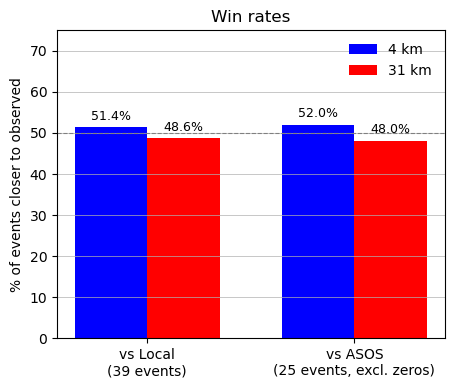

In [9]:
fig, ax1 = plt.subplots(figsize=(5,4), facecolor='white')

categories = ['vs Local\n(39 events)', 'vs ASOS\n(25 events, excl. zeros)']
pct4  = [win4_local/total_local*100,  win4_asos/total_asos*100]
pct31 = [win31_local/total_local*100, win31_asos/total_asos*100]

x = np.arange(len(categories))
w = 0.35

b1 = ax1.bar(x - w/2, pct4,  w, color='b',  label='4 km')
b2 = ax1.bar(x + w/2, pct31, w, color='r', label='31 km')

for bar, val in zip(list(b1)+list(b2), pct4+pct31):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.2,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

ax1.set_xticks(x)
ax1.set_xticklabels(categories)
ax1.set_ylabel('% of events closer to observed')
ax1.set_ylim(0, 75)
ax1.set_title('Win rates')
ax1.axhline(50, color='gray', lw=0.8, ls='--')
ax1.legend(frameon=False)
ax1.grid(axis='y', lw=0.5)

plt.show()

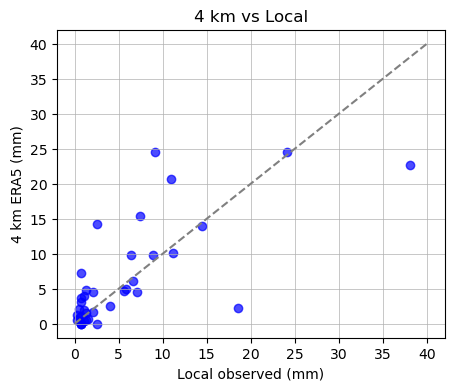

In [10]:
fig, ax3 = plt.subplots(figsize=(5,4), facecolor='white')

maxv = max(df['Local'].max(), df['event4km_sum'].max()) * 1.05
ax3.plot([0, maxv], [0, maxv], '--', color='gray')
ax3.scatter(df['Local'], df['event4km_sum'], color='blue', alpha=0.7)

ax3.set_xlabel('Local observed (mm)')
ax3.set_ylabel('4 km ERA5 (mm)')
ax3.set_title('4 km vs Local')
ax3.grid(lw=0.5)
fig.patch.set_alpha(0)  
plt.show()

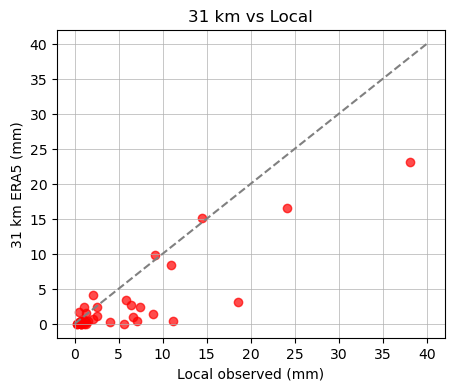

In [11]:
fig, ax4 = plt.subplots(figsize=(5,4), facecolor='white')

maxv2 = max(df['Local'].max(), df['ERA5_31km_mm'].max()) * 1.05
ax4.plot([0, maxv2], [0, maxv2], '--', color='gray')
ax4.scatter(df['Local'], df['ERA5_31km_mm'], color='red', alpha=0.7)

ax4.set_xlabel('Local observed (mm)')
ax4.set_ylabel('31 km ERA5 (mm)')
ax4.set_title('31 km vs Local')
ax4.grid(lw=0.5)
fig.patch.set_alpha(0)  
plt.show()

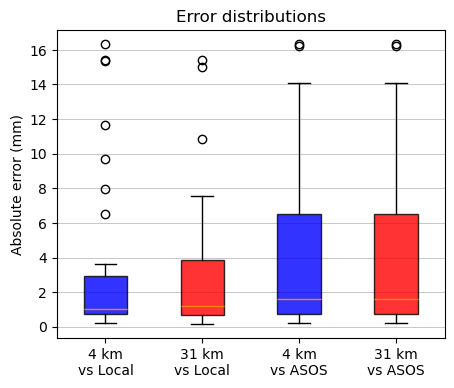

In [12]:
fig, ax5 = plt.subplots(figsize=(5,4), facecolor='white')

data_box = [
    df['diff 4 local'].abs().values,
    df['diff 31 local'].abs().values,
    df_asos['diff 4 asos'].abs().values,
    df_asos['diff 31 asos'].abs().values,]

bp = ax5.boxplot(data_box, patch_artist=True)

colors_box = ['b', 'r', 'b', 'r']
for patch, c in zip(bp['boxes'], colors_box):
    patch.set_facecolor(c)
    patch.set_alpha(0.8)

ax5.set_xticklabels(['4 km\nvs Local','31 km\nvs Local','4 km\nvs ASOS','31 km\nvs ASOS'])
ax5.set_ylabel('Absolute error (mm)')
ax5.set_title('Error distributions')
ax5.grid(axis='y', lw=0.5)

plt.show() 

In [13]:
df['err4']  = df['event4km_sum'] - df['Local']
df['err31'] = df['ERA5_31km_mm'] - df['Local']

over4  = (df['err4']  > 0).sum()
under4 = (df['err4']  < 0).sum()

over31  = (df['err31'] > 0).sum()
under31 = (df['err31'] < 0).sum()

print('4 km:', over4, 'over |', under4, 'under')
print('31 km:', over31, 'over |', under31, 'under')

pct_over4 = over4 / len(df) * 100

4 km: 20 over | 17 under
31 km: 6 over | 31 under


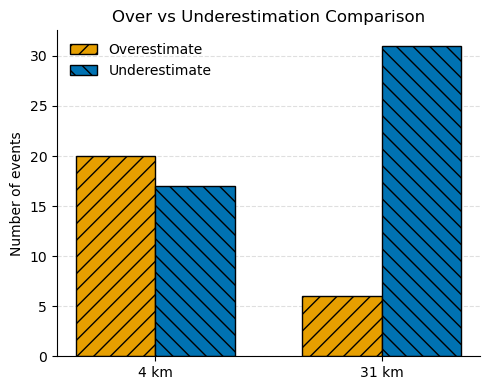

In [14]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5,4))

# Colorblind-safe palette
CB_BLUE   = '#0072B2'
CB_ORANGE = '#E69F00'

labels = ['4 km', '31 km']
over   = [over4, over31]
under  = [under4, under31]

x = np.arange(len(labels))
w = 0.35

# Bars with hatching + strong edges
ax.bar(x - w/2, over,  w,
       color=CB_ORANGE, label='Overestimate',
       hatch='//', edgecolor='black')

ax.bar(x + w/2, under, w,
       color=CB_BLUE, label='Underestimate',
       hatch='\\\\', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Number of events')
ax.set_title('Over vs Underestimation Comparison')

ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', alpha=0.4)

for spine in ['top','right']:
    ax.spines[spine].set_visible(False)

ax.legend(frameon=False)

fig.patch.set_alpha(0)

plt.tight_layout()
plt.show()

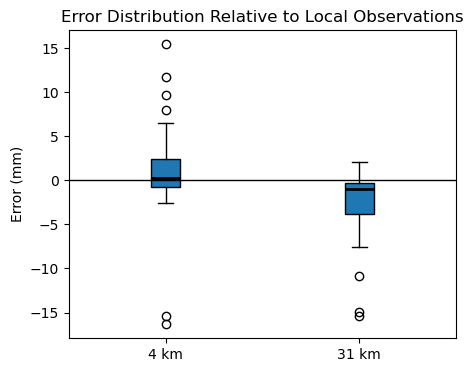

0.24112703037299998 -0.9830000000000001


In [15]:
fig, ax = plt.subplots(figsize=(5,4))

data = [df['err4'], df['err31']]
ax.boxplot(data, patch_artist=True,medianprops=dict(color='black', linewidth=2))

ax.set_xticklabels(['4 km', '31 km'])
ax.set_ylabel('Error (mm)')
ax.set_title('Error Distribution Relative to Local Observations')
ax.axhline(0, color='black', lw=1)
fig.patch.set_alpha(0)
plt.show()


mean_err4 = df['err4'].median()
mean_err31 = df['err31'].median()
print(mean_err4, mean_err31)

In [50]:
df['ratio4']  = df['event4km_sum'] / df['Local']*100
df['ratio31'] = df['ERA5_31km_mm'] / df['Local']*100
# ratio > 1 = overestimate, < 1 = under, 1 = perfect

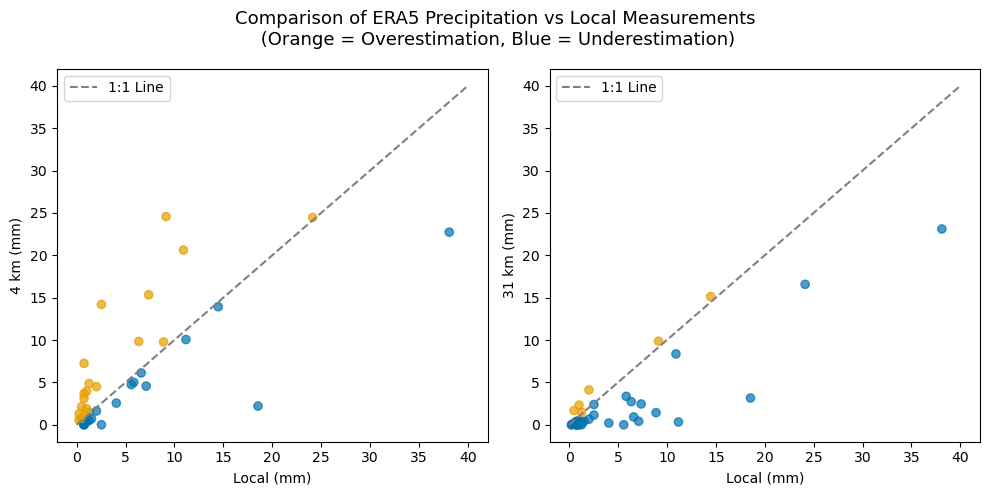

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
for ax, col, label in zip(axes, ['event4km_sum','ERA5_31km_mm'], ['4 km','31 km']):
    colors = np.where(df[col] > df['Local'], CB_ORANGE, CB_BLUE)
    ax.scatter(df['Local'], df[col], c=colors, alpha=0.7)
    maxv = max(df['Local'].max(), df[col].max()) * 1.05
    ax.plot([0,maxv],[0,maxv], '--', color='gray', label='1:1 Line')
    ax.set_xlabel('Local (mm)'); ax.set_ylabel(f'{label} (mm)')
    #ax.set_title(label)
    ax.legend()
    fig.suptitle('Comparison of ERA5 Precipitation vs Local Measurements\n (Orange = Overestimation, Blue = Underestimation)', fontsize=13)
plt.tight_layout()
plt.show()

In [24]:
corr_4km = df['Local'].corr(df['event4km_sum'])
print(corr_4km)
corr_31km = df['Local'].corr(df['ERA5_31km_mm'])
print(corr_31km)

0.7239963226121773
0.8686755114501943


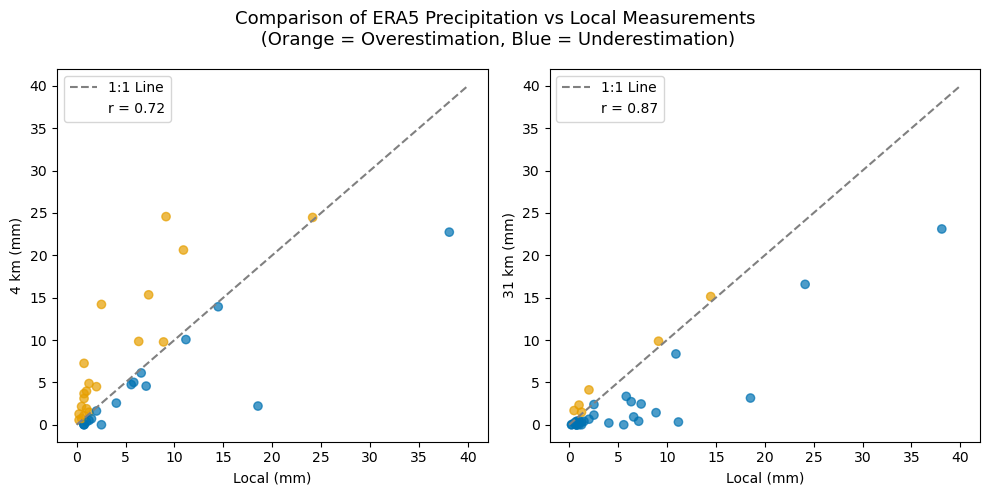

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))

for ax, col, label in zip(axes, ['event4km_sum','ERA5_31km_mm'], ['4 km','31 km']):
    # 1. Calculate the Pearson correlation coefficient
    r_value = df['Local'].corr(df[col])
    
    colors = np.where(df[col] > df['Local'], CB_ORANGE, CB_BLUE)
    ax.scatter(df['Local'], df[col], c=colors, alpha=0.7)
    
    maxv = max(df['Local'].max(), df[col].max()) * 1.05
    ax.plot([0,maxv],[0,maxv], '--', color='gray', label='1:1 Line')
    
    ax.set_xlabel('Local (mm)')
    ax.set_ylabel(f'{label} (mm)')
    
    # 2. Add the correlation to the legend dynamically
    ax.plot([], [], ' ', label=f'r = {r_value:.2f}') 
    ax.legend()

fig.suptitle('Comparison of ERA5 Precipitation vs Local Measurements\n (Orange = Overestimation, Blue = Underestimation)', fontsize=13)
plt.tight_layout()
plt.show()

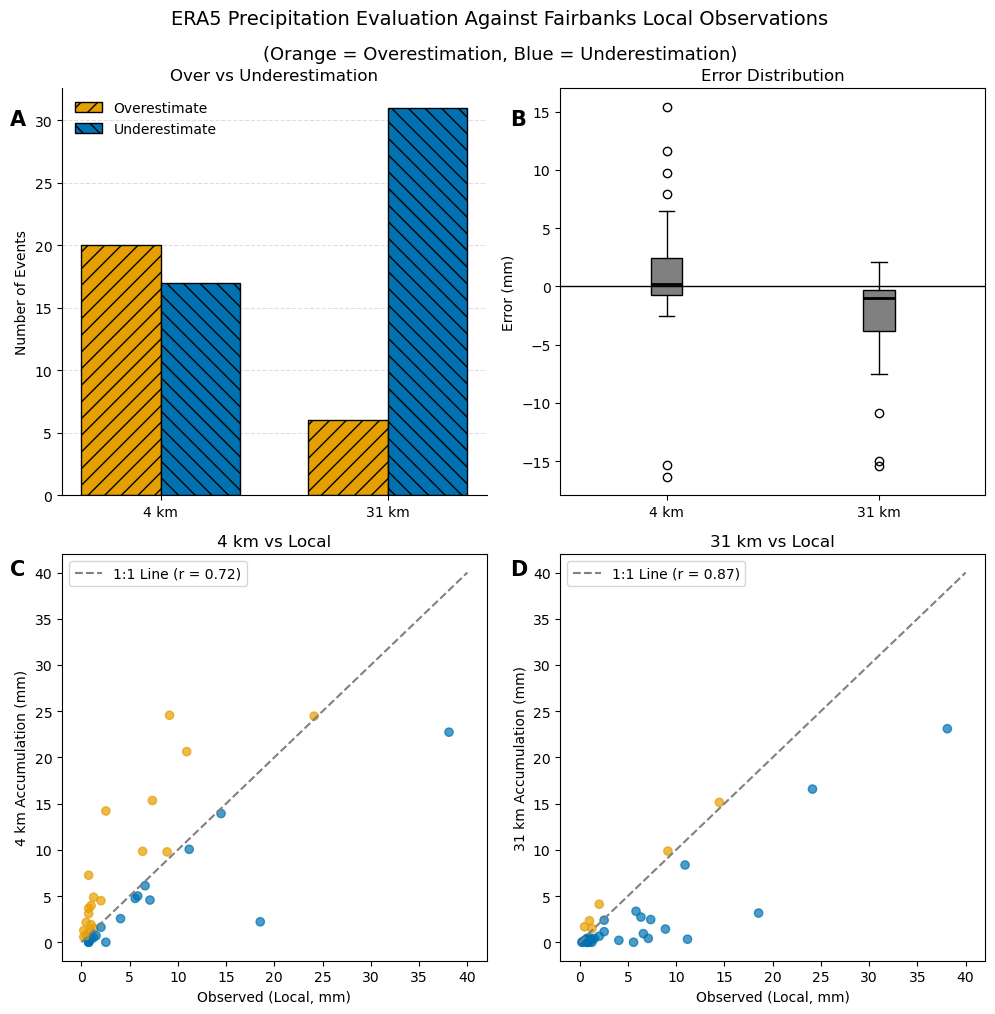

In [37]:
CB_BLUE   = '#0072B2'
CB_ORANGE = '#E69F00'

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

ax = axes[0, 0]
labels = ['4 km', '31 km']
over   = [over4, over31]
under  = [under4, under31]

x = np.arange(len(labels))
w = 0.35

ax.bar(x - w/2, over,  w,
       color=CB_ORANGE, label='Overestimate',
       hatch='//', edgecolor='black')

ax.bar(x + w/2, under, w,
       color=CB_BLUE, label='Underestimate',
       hatch='\\\\', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Number of Events')
ax.set_title('Over vs Underestimation')

ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

for spine in ['top','right']:
    ax.spines[spine].set_visible(False)
ax.legend(frameon=False)
ax = axes[0, 1]
data = [df['err4'], df['err31']]
ax.boxplot(data, patch_artist=True,boxprops=dict(facecolor='gray',color='black'), medianprops=dict(color='black', linewidth=2))

ax.set_xticklabels(['4 km', '31 km'])
ax.set_ylabel('Error (mm)')
ax.set_title('Error Distribution')
ax.axhline(0, color='black', lw=1)
ax = axes[1, 0]
colors = np.where(df['event4km_sum'] > df['Local'], CB_ORANGE, CB_BLUE)
ax.scatter(df['Local'], df['event4km_sum'], c=colors, alpha=0.7)
maxv = max(df['Local'].max(), df['event4km_sum'].max()) * 1.05
ax.plot([0, maxv], [0, maxv], '--', color='gray', label=f'1:1 Line (r = {corr_4km:.2f})')
ax.set_xlabel('Observed (Local, mm)')
ax.set_ylabel('4 km Accumulation (mm)')
ax.set_title('4 km vs Local')
ax.legend()


ax = axes[1, 1]
colors = np.where(df['ERA5_31km_mm'] > df['Local'], CB_ORANGE, CB_BLUE)
ax.scatter(df['Local'], df['ERA5_31km_mm'], c=colors, alpha=0.7)
maxv = max(df['Local'].max(), df['ERA5_31km_mm'].max()) * 1.05
ax.plot([0, maxv], [0, maxv], '--', color='gray',label=f'1:1 Line (r = {corr_31km:.2f})')
ax.set_xlabel('Observed (Local, mm)')
ax.set_ylabel('31 km Accumulation (mm)')
ax.set_title('31 km vs Local')
ax.legend()


fig.suptitle(
    'ERA5 Precipitation Evaluation Against Fairbanks Local Observations',
    fontsize=14, y=1.01)
fig.text(
    0.5, 0.96,
    '(Orange = Overestimation, Blue = Underestimation)',
    ha='center',
    fontsize=13)

plt.tight_layout()

fig.text(0.01, .91, 'A', fontsize=15, fontweight='bold', va='top', ha='left')
fig.text(0.51, .91, 'B', fontsize=15, fontweight='bold', va='top', ha='left')
fig.text(0.01, .46, 'C', fontsize=15, fontweight='bold', va='top', ha='left')
fig.text(0.51, .46, 'D', fontsize=15, fontweight='bold', va='top', ha='left')
fig.patch.set_alpha(0)
plt.show()

In [154]:

mean_bias_4km = df['err4'].mean()
mean_bias_31km = df['err31'].mean()

print(mean_bias_4km, mean_bias_31km)

0.7518750072492701 -2.6623783783783783
